# Train, predict, score, and evaluate a CNN on PLAsTiCC (Boone GP features)



In [ ]:


CONFIG_DEFAULT_PATH = '/home6/s4339150/Courses/dlip_plasticc/configs/default.toml'
CONFIG_LOCAL_PATH   = '/home6/s4339150/Courses/dlip_plasticc/configs/local.toml'

TRAIN_DATASET_NAME  = 'plasticc_augment'
CLASSIFIER_NAME     = 'my_cnn_gp'
NUM_EPOCHS          = 500
BATCH_SIZE          = 64
LR                  = 1e-3
AUTO_CLASS_WEIGHTS  = True


NUM_FOLDS               = 5
RANDOM_STATE            = 42
VAL_FOLD                = 0
WEIGHT_DECAY            = 1e-4
LR_SCHEDULER_FACTOR     = 0.5
LR_SCHEDULER_PATIENCE   = 3
MIN_LR                  = 1e-6
EARLY_STOPPING_PATIENCE = 15


TRAIN_FEATURE_PATH = '/scratch/s4339150/plasticc/features/features_plasticc_augment.h5'
TRAIN_FEATURE_KEY  = 'raw_features'


TEST_DATASET_NAME = 'plasticc_test'
TOTAL_CHUNKS      = 500
CHUNKS            = range(21)

FEATURE_BASE    = '/scratch/s4339150/plasticc/features/chunks/test/'
FEATURE_PATTERN = 'features_test_chunk_{chunk}_plasticc_test.h5'
FEATURE_KEY     = 'raw_features'

OUT_DIR = 'notebook_outputs/cnn_gp_predictions'


CONFUSION_NORMALIZE = 'true'
FIGSIZE_HISTORY     = (8, 5)
FIGSIZE_CONFUSION   = (10, 8)

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import avocado

from dlip_plasticc.config import load_config, apply_avocado_settings
from dlip_plasticc.features.adapters import ReshapeFeaturizer
from dlip_plasticc.models import CNNClassifier
from dlip_plasticc.pipelines.predict import predict_partial_from_feature_chunks
from dlip_plasticc.pipelines.score import score_flat, align_truth_and_predictions

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [51]:
# Load config and apply avocado settings
config = load_config(CONFIG_DEFAULT_PATH, CONFIG_LOCAL_PATH)
apply_avocado_settings(config)

In [52]:
gp_featurizer  = avocado.plasticc.PlasticcFeaturizer()
cnn_featurizer = ReshapeFeaturizer(gp_featurizer)

classifier = CNNClassifier(
    name=CLASSIFIER_NAME,
    featurizer=cnn_featurizer,
    num_epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    auto_class_weights=AUTO_CLASS_WEIGHTS,
)

In [53]:
print(f"Loading training dataset '{TRAIN_DATASET_NAME}'...")
train_dataset = avocado.load(TRAIN_DATASET_NAME, metadata_only=True)
print(f"Training samples: {len(train_dataset.metadata)}")

Loading training dataset 'plasticc_augment'...
Training samples: 66532


In [ ]:
# Inspect keys 
train_feature_path = Path(TRAIN_FEATURE_PATH)

print(f"Inspecting HDF5 keys in: {train_feature_path}")
with pd.HDFStore(train_feature_path, mode="r") as store:
    print(store.keys())

Inspecting HDF5 keys in: /scratch/s4339150/plasticc/features/features_plasticc_augment.h5
['/raw_features']


In [35]:
print("Loading precomputed raw GP features...")
train_raw_features = pd.read_hdf(train_feature_path, key=TRAIN_FEATURE_KEY)

# If object_id is stored as a normal column, move it to the index
if "object_id" in train_raw_features.columns:
    train_raw_features = train_raw_features.set_index("object_id")

print("Raw feature table shape:", train_raw_features.shape)
print("First feature rows:")
display(train_raw_features.head())

Loading precomputed raw GP features...


Raw feature table shape: (66532, 230)
First feature rows:


,host_specz,host_photoz,host_photoz_error,ra,decl,mwebv,ddf,count,gp_fit_0,gp_fit_1,...,peaks_neg_lsstr_frac_3,peaks_neg_lssti_count,peaks_neg_lssti_frac_2,peaks_neg_lssti_frac_3,peaks_neg_lsstz_count,peaks_neg_lsstz_frac_2,peaks_neg_lsstz_frac_3,peaks_neg_lssty_count,peaks_neg_lssty_frac_2,peaks_neg_lssty_frac_3
object_id,,,,,,,,,,,,,,,,,,,,,
plasticc_000000615,0.0,0.0,0.0,349.0461,-61.9438,0.017000,True,352,11.133501,0.810587,...,0.986609,19,0.979853,0.944808,20,0.983326,0.979975,25,0.996985,0.992113
plasticc_000000615_aug_LVOEbJnHTA,0.0,0.0,0.0,349.0461,-61.9438,0.018169,False,98,10.642495,0.159404,...,0.948243,15,0.966426,0.889145,17,0.942445,0.891381,18,0.827324,0.824190
plasticc_000000615_aug_NFlmSZYofd,0.0,0.0,0.0,349.0461,-61.9438,0.017042,False,143,10.833813,2.504689,...,0.889738,16,0.730213,0.695306,16,0.631030,0.620007,16,0.928686,0.840662
plasticc_000000615_aug_QDFBWSNCds,0.0,0.0,0.0,349.0461,-61.9438,0.016789,False,108,10.481543,1.857385,...,0.524515,14,0.498239,0.453317,16,0.588691,0.558322,15,0.778549,0.631299
plasticc_000000615_aug_UhfaFwXxsD,0.0,0.0,0.0,349.0461,-61.9438,0.015208,False,144,12.288021,2.438968,...,0.943839,13,0.960159,0.905953,12,0.751887,0.728960,13,0.780721,0.755846


In [ ]:

missing_ids = train_dataset.metadata.index.difference(train_raw_features.index)
extra_ids   = train_raw_features.index.difference(train_dataset.metadata.index)

print("Missing feature rows:", len(missing_ids))
print("Extra feature rows:", len(extra_ids))

if len(missing_ids) > 0:
    print("Example missing ids:", list(missing_ids[:10]))
if len(extra_ids) > 0:
    print("Example extra ids:", list(extra_ids[:10]))

Missing feature rows: 0
Extra feature rows: 0


## 1. Train the CNN


In [56]:
print(f"Training classifier '{CLASSIFIER_NAME}' from precomputed raw features...")
classifier.train(
    train_dataset,
    raw_features=train_raw_features,
    num_folds=NUM_FOLDS,
    random_state=RANDOM_STATE,
    val_fold=VAL_FOLD,
    weight_decay=WEIGHT_DECAY,
    lr_scheduler_factor=LR_SCHEDULER_FACTOR,
    lr_scheduler_patience=LR_SCHEDULER_PATIENCE,
    min_lr=MIN_LR,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    show_progress=True,
)

print(f"Best validation loss: {classifier.best_val_loss:.5f}")
print(f"Validation fold: {classifier.val_fold}")
print("Detected classes:", classifier.class_names)

Training classifier 'my_cnn_gp' from precomputed raw features...


Epochs:   0%|          | 1/500 [00:01<16:04,  1.93s/it]

Epoch 1  train=2.47192  val=2.29115  acc=0.1521  lr=1.00e-04


Epochs:   0%|          | 2/500 [00:03<15:22,  1.85s/it]

Epoch 2  train=2.21283  val=2.19865  acc=0.1772  lr=1.00e-04


...

Epoch 93  train=1.44795  val=1.52376  acc=0.3974  lr=1.56e-06


Epochs:  19%|█▉        | 94/500 [02:50<13:58,  2.07s/it]

Epoch 94  train=1.44693  val=1.52476  acc=0.3958  lr=1.56e-06


Epochs:  19%|█▉        | 94/500 [02:51<12:22,  1.83s/it]


KeyboardInterrupt: 

In [38]:
classifier.write(overwrite=True)
print('Classifier written to:', classifier.path)

Classifier written to: /scratch/s4339150/plasticc/classifiers/classifier_my_cnn_gp.pkl


## 2. Plot training history


In [39]:
history = classifier.history.copy()
history.tail()


,epoch,train_loss,val_loss,val_acc,lr
105,106,0.597268,0.715768,0.711796,0.000016
106,107,0.597998,0.716829,0.714788,0.000008
107,108,0.597675,0.716308,0.713442,0.000008
108,109,0.596156,0.716548,0.712993,0.000008
109,110,0.594055,0.716681,0.713741,0.000008


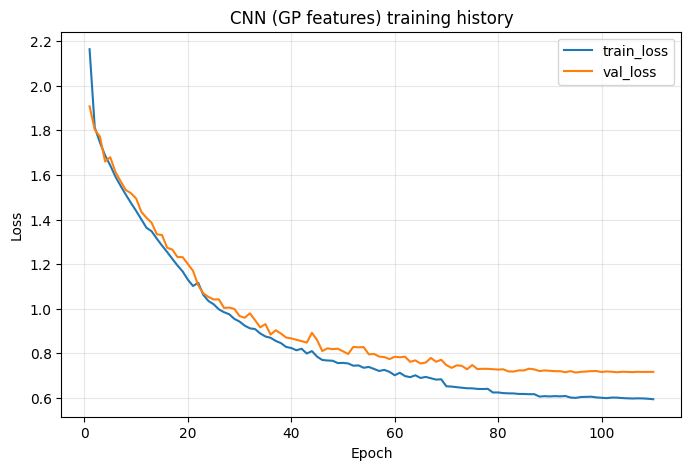

In [40]:
fig, ax = plt.subplots(figsize=FIGSIZE_HISTORY)
ax.plot(history['epoch'], history['train_loss'], label='train_loss')
ax.plot(history['epoch'], history['val_loss'],   label='val_loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('CNN (GP features) training history')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


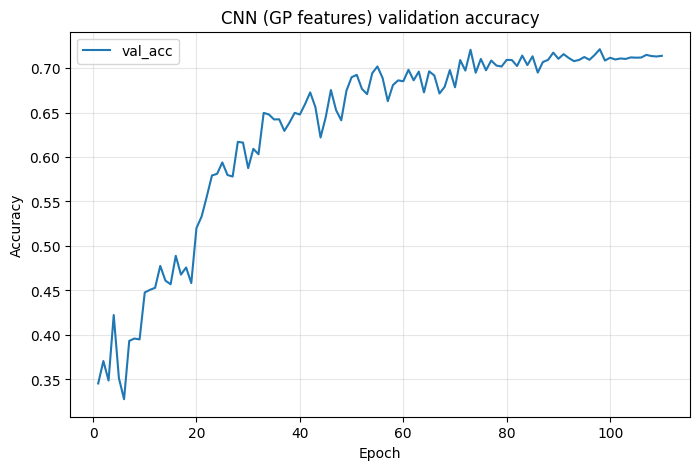

In [41]:
fig, ax = plt.subplots(figsize=FIGSIZE_HISTORY)
ax.plot(history['epoch'], history['val_acc'], label='val_acc')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('CNN (GP features) validation accuracy')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


## 3. Predict on test chunks

GP features are precomputed so we use the fast `predict_partial_from_feature_chunks`
path — no observation loading required.

In [42]:
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

combined_predictions, processed_chunks = predict_partial_from_feature_chunks(
    classifier=classifier,
    dataset_name=TEST_DATASET_NAME,
    total_chunks=TOTAL_CHUNKS,
    chunks=CHUNKS,
    feature_base=FEATURE_BASE,
    feature_pattern=FEATURE_PATTERN,
    feature_key=FEATURE_KEY,
    out_dir=OUT_DIR,
    show_progress=True,
)

print('Processed chunks:', processed_chunks)
print('Combined prediction shape:', combined_predictions.shape)
combined_predictions.head()

Chunks: 100%|██████████| 21/21 [00:04<00:00,  5.05it/s]


Processed chunks: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Combined prediction shape: (146701, 14)


,6,15,16,42,52,53,62,64,65,67,88,90,92,95
object_id,,,,,,,,,,,,,,
plasticc_000000013,2.087764e-15,5.013233e-03,2.133780e-14,0.438092,0.409507,1.316946e-16,0.033589,5.292177e-07,4.759852e-16,0.001623,1.121912e-04,0.111843,6.371864e-16,0.000220
plasticc_000000014,1.956363e-20,2.414134e-01,2.092263e-14,0.209065,0.051319,9.860598e-18,0.002016,7.292097e-06,4.261572e-17,0.000376,4.290789e-01,0.066642,1.130337e-10,0.000083
plasticc_000000017,3.692198e-20,5.240888e-04,2.171680e-15,0.674778,0.105214,6.088282e-22,0.007657,1.156553e-02,2.594215e-17,0.001871,4.657999e-02,0.151648,2.175049e-12,0.000163
plasticc_000000023,2.758760e-17,4.995556e-05,2.388593e-16,0.070671,0.102493,1.310594e-17,0.178619,7.504652e-06,4.981024e-18,0.443771,7.141364e-07,0.202289,2.864632e-17,0.002099
plasticc_000000034,2.172408e-21,6.491184e-07,1.270121e-20,0.094520,0.301494,5.955821e-22,0.057774,6.573875e-08,1.159069e-20,0.003473,1.229520e-05,0.539650,3.439405e-19,0.003076


## 4. Score predictions with avocado flat-weighted log-loss

In [47]:
flat_score, n_scored = score_flat(TEST_DATASET_NAME, combined_predictions)
print(f'Flat-weighted log-loss: {flat_score:.5f}')
print(f'Objects scored:         {n_scored:,}')

Flat-weighted log-loss: inf
Objects scored:         146,085


/home6/s4339150/miniconda/envs/project/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


## 5. Confusion matrix

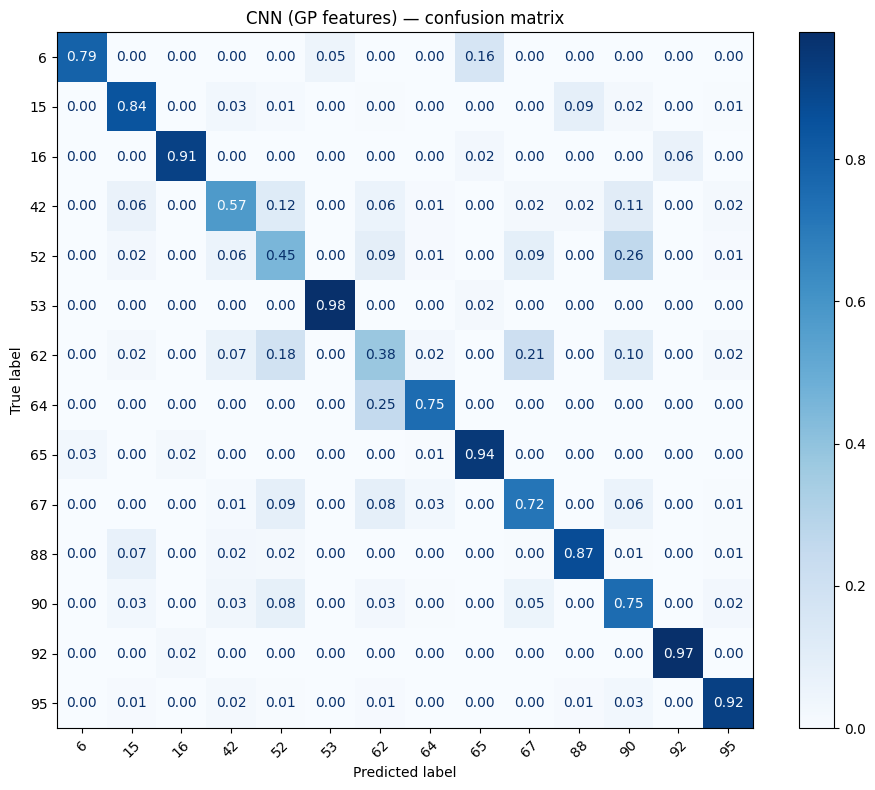

In [48]:
y_true, pred_aligned = align_truth_and_predictions(
    TEST_DATASET_NAME,
    combined_predictions,
    known_classes_only=True,
    normalize=True,
)

y_pred  = pred_aligned.idxmax(axis=1)
labels  = sorted(np.unique(np.concatenate([y_true.values, y_pred.values])))

cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=CONFUSION_NORMALIZE)

fig, ax = plt.subplots(figsize=FIGSIZE_CONFUSION)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, xticks_rotation=45, colorbar=True,
          cmap=plt.cm.Blues, values_format='.2f')
ax.set_title('CNN (GP features) — confusion matrix')
plt.tight_layout()
plt.show()

In [45]:
print(classification_report(y_true, y_pred, digits=4))

              precision    recall  f1-score   support

           6     0.2313    0.7907    0.3579        43
          15     0.0682    0.8413    0.1262       479
          16     0.9328    0.9106    0.9216      3233
          42     0.9020    0.5735    0.7012     48142
          52     0.0911    0.4536    0.1517      2864
          53     0.8036    0.9783    0.8824        46
          62     0.3755    0.3755    0.3755      7859
          64     0.0059    0.7500    0.0117         8
          65     0.9666    0.9435    0.9549      3095
          67     0.1610    0.7161    0.2629      1673
          88     0.7184    0.8688    0.7865      3743
          90     0.8772    0.7513    0.8094     66848
          92     0.9683    0.9745    0.9714      6781
          95     0.2899    0.9150    0.4403      1271

    accuracy                         0.6890    146085
   macro avg     0.5280    0.7745    0.5538    146085
weighted avg     0.8300    0.6890    0.7381    146085

